In [1]:
import pandas as pd
df = pd.read_csv('account_data.csv')

In [2]:
df.isna().any()

Age                          False
Occupation                   False
MaritalStatus                False
Dependents                   False
ResidentialStatus            False
AddressDuration              False
CreditScore                  False
IncomeLevel                  False
LoanAmountRequested          False
LoanTerm                     False
PurposeoftheLoan             False
Collateral                   False
InterestRate                 False
PreviousLoans                False
ExistingLiabilities          False
ApplicationBehavior          False
LocationofApplication        False
ChangeinBehavior             False
TimeofTransaction            False
AccountActivity              False
PaymentBehavior              False
Blacklists                   False
EmploymentVerification       False
PastFinancialMalpractices    False
DeviceInformation            False
SocialMediaFootprint         False
ConsistencyinData            False
Referral                     False
IsFraud             

In [3]:
df.duplicated().any()

np.False_

In [4]:
for i in df:
    print(df[i].unique(),i)
    print('_'*100)

[56 40 25 34 47 22 26 37 31 36 41 27 35 46 43 30 23 52 38 28 45 39 48 33
 42 29 32 53 24 54 55 44 51 49 50] Age
____________________________________________________________________________________________________
<StringArray>
[           'Teacher',           'Engineer',              'Clerk',
         'Unemployed', 'Software Developer',           'Designer',
         'Technician',            'Manager',       'Entrepreneur',
           'Musician',             'Lawyer',             'Doctor',
             'Artist',         'Accountant',      'Self-employed',
          'Architect',               'Chef',            'Retired',
            'Student']
Length: 19, dtype: str Occupation
____________________________________________________________________________________________________
<StringArray>
['Divorced', 'Single', 'Married']
Length: 3, dtype: str MaritalStatus
____________________________________________________________________________________________________
[4 0 1 2 3] Dependents
_____

In [5]:
df.drop(["PaymentBehavior","AccountActivity","PastFinancialMalpractices","Blacklists","ConsistencyinData","ChangeinBehavior","EmploymentVerification","ApplicationBehavior","TimeofTransaction"],axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  int64  
 1   Occupation             10000 non-null  str    
 2   MaritalStatus          10000 non-null  str    
 3   Dependents             10000 non-null  int64  
 4   ResidentialStatus      10000 non-null  str    
 5   AddressDuration        10000 non-null  int64  
 6   CreditScore            10000 non-null  int64  
 7   IncomeLevel            10000 non-null  int64  
 8   LoanAmountRequested    10000 non-null  int64  
 9   LoanTerm               10000 non-null  int64  
 10  PurposeoftheLoan       10000 non-null  str    
 11  Collateral             10000 non-null  str    
 12  InterestRate           10000 non-null  float64
 13  PreviousLoans          10000 non-null  int64  
 14  ExistingLiabilities    10000 non-null  int64  
 15  LocationofAppl

In [7]:
df['IsFraud']=df['IsFraud'].replace({'Yes':1,'No':0})
df['SocialMediaFootprint']=df['SocialMediaFootprint'].replace({'Yes':1,'No':0})
df['IsFraud']=df['IsFraud'].astype(int)
df['SocialMediaFootprint']=df['SocialMediaFootprint'].astype(int)

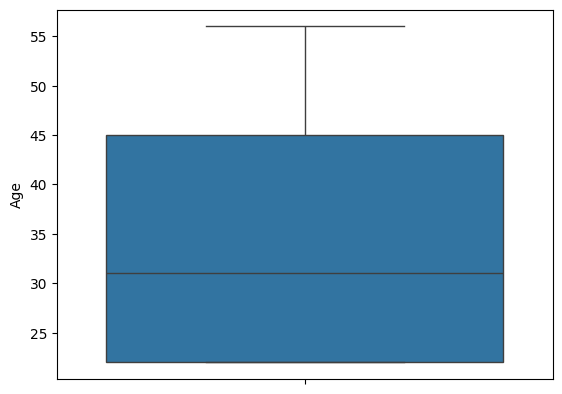

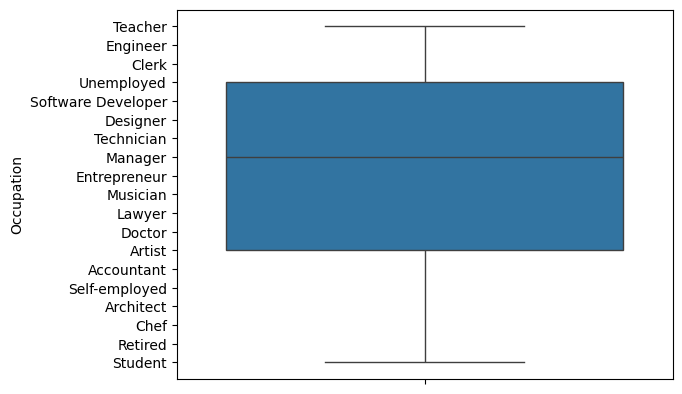

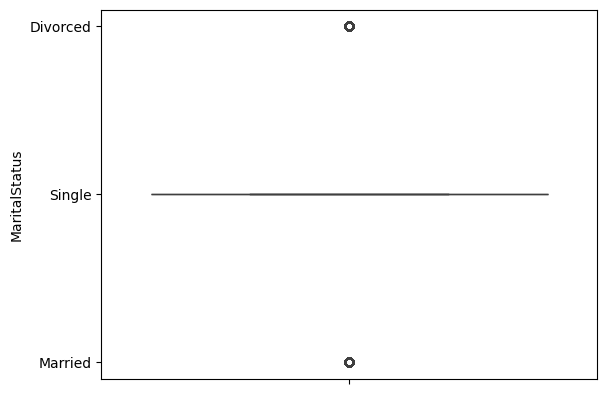

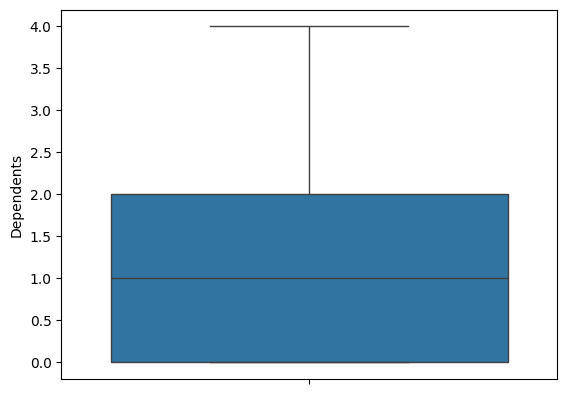

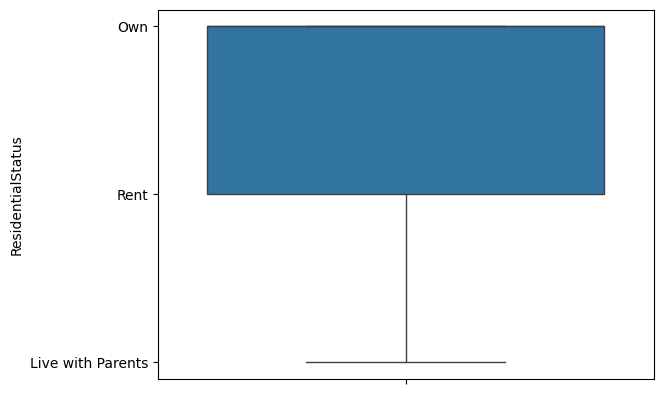

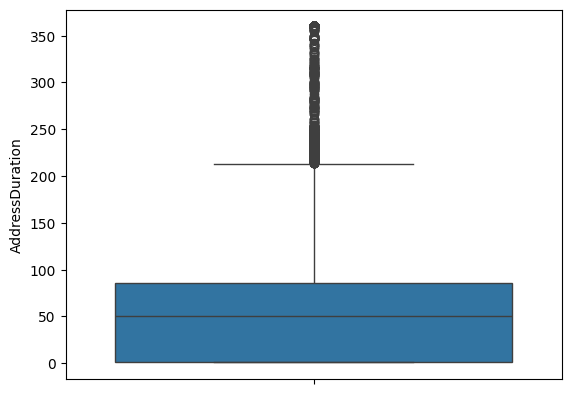

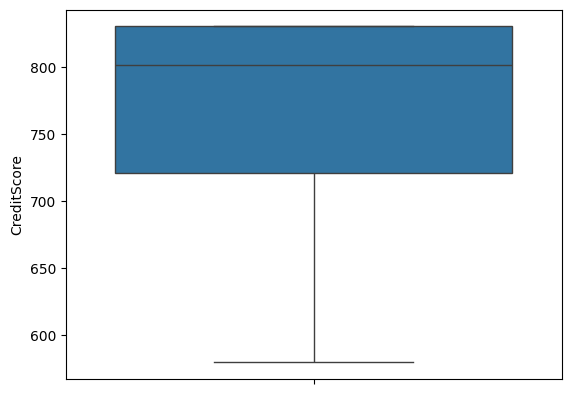

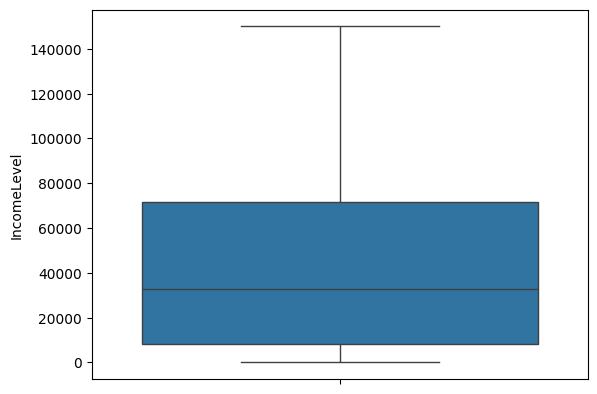

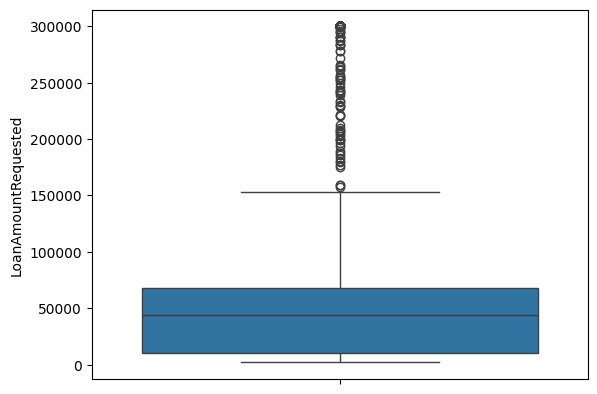

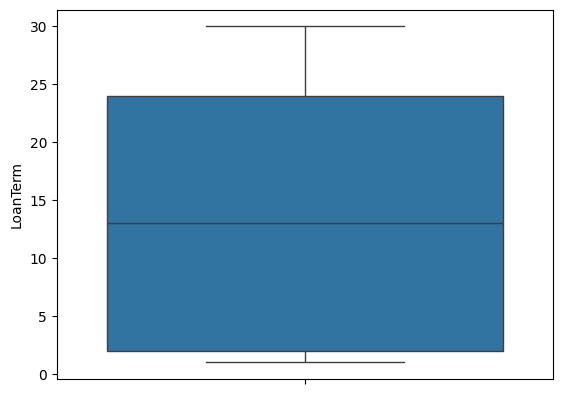

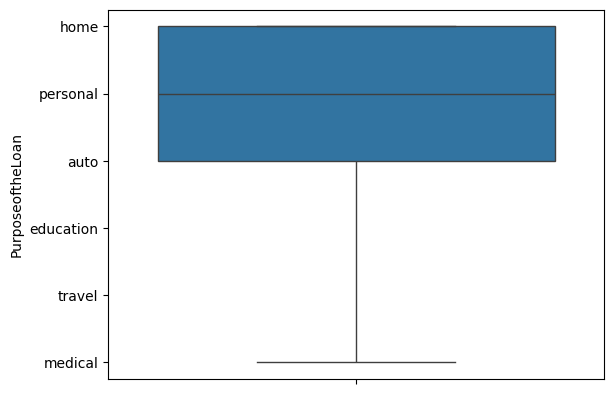

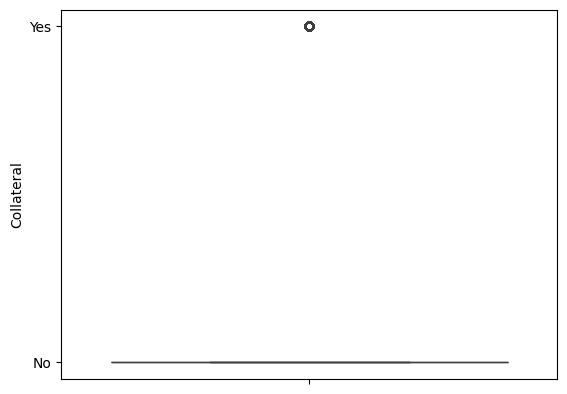

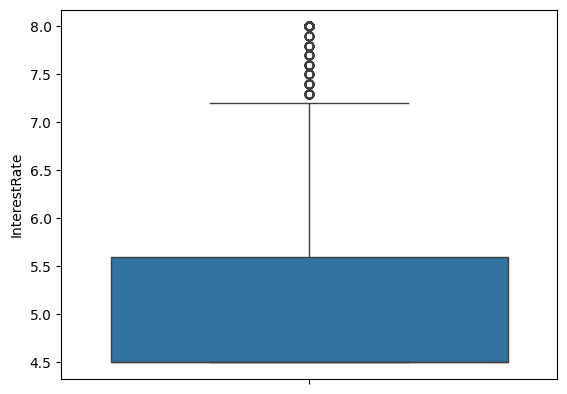

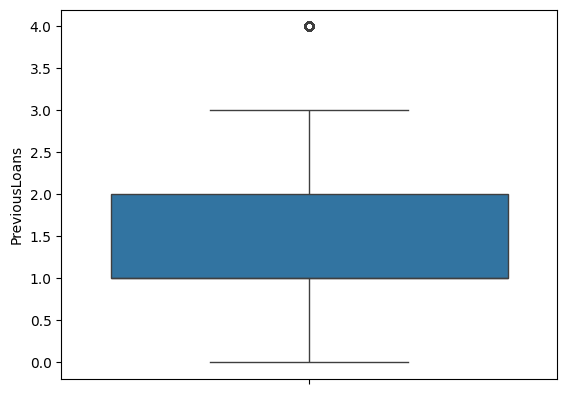

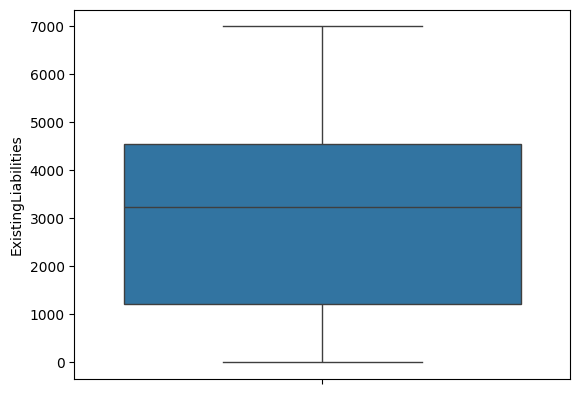

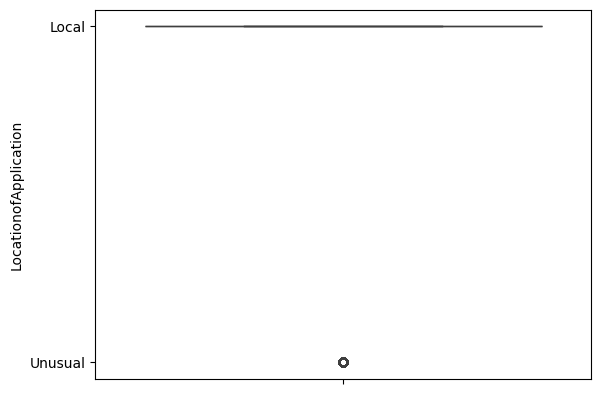

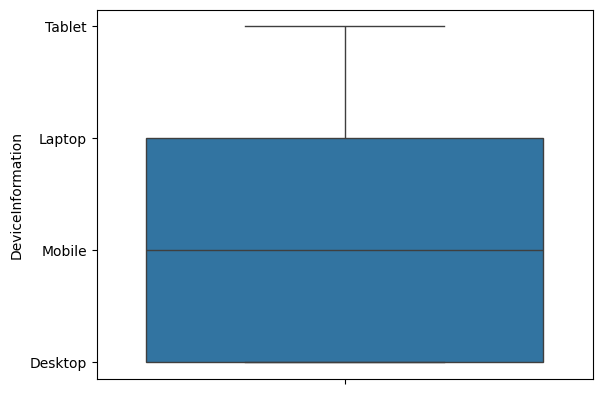

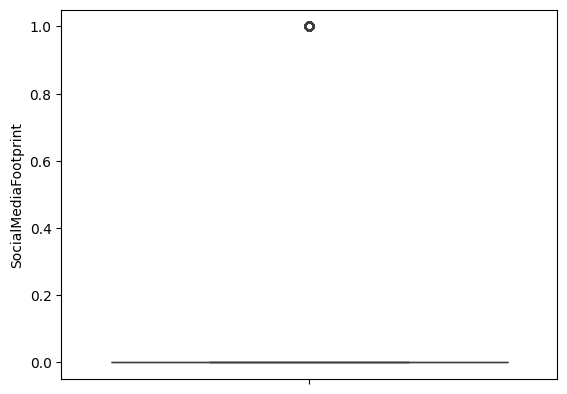

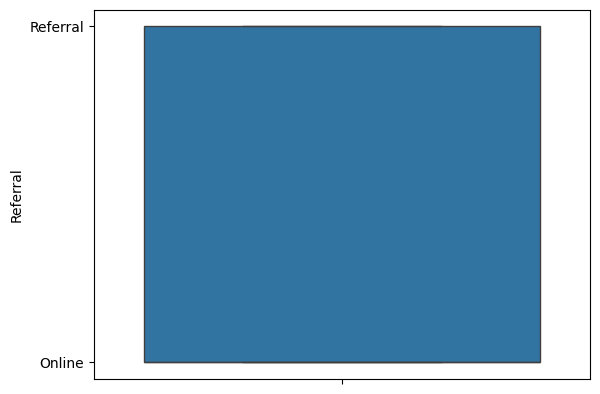

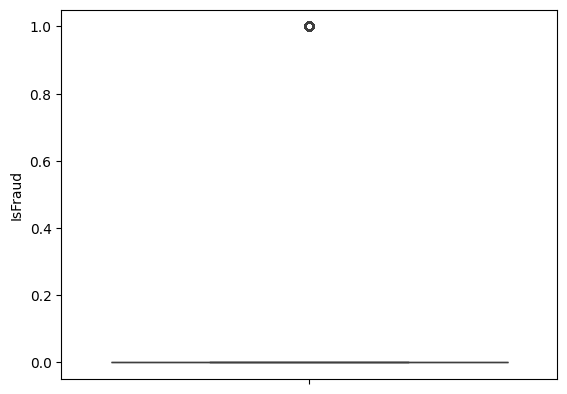

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

In [40]:
q1 = df['PreviousLoans'].quantile(.25)
q3 = df['PreviousLoans'].quantile(.75)
iqr = q3 - q1
lw = q1-(iqr*1.5)
uw = q3+(iqr*1.5)
outlayers = df[df['PreviousLoans']>uw]
outlayers
df.drop(outlayers.index,inplace=True)

In [35]:
q1 = df['AddressDuration'].quantile(.25)
q3 = df['AddressDuration'].quantile(.75)
iqr = q3 - q1
lw = q1-(iqr*1.5)
uw = q3+(iqr*1.5)
outlayers1 = df[df['AddressDuration']>uw]
outlayers1
df.drop(outlayers1.index,inplace=True)

In [36]:
outlayers1

,Age,Occupation,MaritalStatus,Dependents,ResidentialStatus,AddressDuration,CreditScore,IncomeLevel,LoanAmountRequested,LoanTerm,PurposeoftheLoan,Collateral,InterestRate,PreviousLoans,ExistingLiabilities,LocationofApplication,DeviceInformation,SocialMediaFootprint,Referral,IsFraud


In [41]:
from sklearn.preprocessing import OneHotEncoder
ohn = OneHotEncoder(sparse_output=True)
df1 = ohn.fit_transform(df[['Occupation']])
dff = df1.toarray()
df1 = pd.DataFrame(dff,columns=ohn.get_feature_names_out())
df1

,Occupation_Accountant,Occupation_Architect,Occupation_Artist,Occupation_Chef,Occupation_Clerk,Occupation_Designer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Lawyer,Occupation_Manager,Occupation_Musician,Occupation_Retired,Occupation_Self-employed,Occupation_Software Developer,Occupation_Student,Occupation_Teacher,Occupation_Technician,Occupation_Unemployed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8211,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [42]:
ohn1 = OneHotEncoder(sparse_output=True)
df2 = ohn1.fit_transform(df[['MaritalStatus']])
dff = df2.toarray()
df2 = pd.DataFrame(dff,columns=ohn1.get_feature_names_out())
df2

,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
8211,1.0,0.0,0.0
8212,0.0,0.0,1.0
8213,0.0,0.0,1.0
8214,0.0,0.0,1.0


In [44]:
ohn2 = OneHotEncoder(sparse_output=True)
df3 = ohn2.fit_transform(df[['ResidentialStatus']])
dff = df3.toarray()
df3 = pd.DataFrame(dff,columns=ohn2.get_feature_names_out())
df3

,ResidentialStatus_Live with Parents,ResidentialStatus_Own,ResidentialStatus_Rent
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
8211,0.0,1.0,0.0
8212,0.0,1.0,0.0
8213,0.0,0.0,1.0
8214,0.0,0.0,1.0


In [46]:
ohn3 = OneHotEncoder(sparse_output=True)
df4 = ohn3.fit_transform(df[['PurposeoftheLoan']])
dff = df4.toarray()
df4 = pd.DataFrame(dff,columns=ohn3.get_feature_names_out())
df4

,PurposeoftheLoan_auto,PurposeoftheLoan_education,PurposeoftheLoan_home,PurposeoftheLoan_medical,PurposeoftheLoan_personal,PurposeoftheLoan_travel
0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
8211,0.0,0.0,1.0,0.0,0.0,0.0
8212,0.0,0.0,0.0,1.0,0.0,0.0
8213,0.0,0.0,0.0,0.0,1.0,0.0
8214,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
ohn4 = OneHotEncoder(sparse_output=True)
df5 = ohn4.fit_transform(df[['Collateral']])
dff = df5.toarray()
df5= pd.DataFrame(dff,columns=ohn4.get_feature_names_out())
df5

,Collateral_No,Collateral_Yes
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
8211,0.0,1.0
8212,1.0,0.0
8213,1.0,0.0
8214,1.0,0.0


In [48]:
ohn5 = OneHotEncoder(sparse_output=True)
df6 = ohn5.fit_transform(df[['LocationofApplication']])
dff = df6.toarray()
df6= pd.DataFrame(dff,columns=ohn5.get_feature_names_out())
df6

,LocationofApplication_Local,LocationofApplication_Unusual
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
8211,1.0,0.0
8212,1.0,0.0
8213,0.0,1.0
8214,0.0,1.0


In [49]:
ohn6 = OneHotEncoder(sparse_output=True)
df7 = ohn6.fit_transform(df[['DeviceInformation']])
dff = df7.toarray()
df7= pd.DataFrame(dff,columns=ohn6.get_feature_names_out())
df7

,DeviceInformation_Desktop,DeviceInformation_Laptop,DeviceInformation_Mobile,DeviceInformation_Tablet
0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
8211,1.0,0.0,0.0,0.0
8212,1.0,0.0,0.0,0.0
8213,0.0,0.0,1.0,0.0
8214,0.0,0.0,1.0,0.0


In [50]:
ohn7 = OneHotEncoder(sparse_output=True)
df8 = ohn7.fit_transform(df[['Referral']])
dff = df8.toarray()
df8= pd.DataFrame(dff,columns=ohn7.get_feature_names_out())
df8

,Referral_Online,Referral_Referral
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
8211,0.0,1.0
8212,0.0,1.0
8213,1.0,0.0
8214,1.0,0.0


In [51]:
dff1 = pd.concat([df,df1,df2,df3,df4,df5,df6,df7,df8],axis=1)

In [52]:
dff1.drop(["Occupation","MaritalStatus","ResidentialStatus","PurposeoftheLoan","Collateral","LocationofApplication","DeviceInformation","Referral"],axis=1,inplace=True)

In [53]:
dff1.corr()['IsFraud']

Age                                   -0.281986
Dependents                            -0.228521
AddressDuration                        0.067913
CreditScore                           -0.174840
IncomeLevel                           -0.249171
LoanAmountRequested                   -0.201329
LoanTerm                              -0.310833
InterestRate                           0.087771
PreviousLoans                         -0.122166
ExistingLiabilities                    0.033208
SocialMediaFootprint                  -0.171314
IsFraud                                1.000000
Occupation_Accountant                  0.007803
Occupation_Architect                   0.020249
Occupation_Artist                     -0.002598
Occupation_Chef                       -0.010982
Occupation_Clerk                       0.006212
Occupation_Designer                   -0.021016
Occupation_Doctor                     -0.000876
Occupation_Engineer                   -0.008570
Occupation_Entrepreneur               -0

In [54]:
dff1['IsFraud'].value_counts()

IsFraud
0.0    6047
1.0    2169
Name: count, dtype: int64

In [23]:
x= dff1.drop('IsFraud',axis=1)
y = dff1[['IsFraud']]

In [56]:
x

,Age,Dependents,AddressDuration,CreditScore,IncomeLevel,LoanAmountRequested,LoanTerm,InterestRate,PreviousLoans,ExistingLiabilities,...,Collateral_No,Collateral_Yes,LocationofApplication_Local,LocationofApplication_Unusual,DeviceInformation_Desktop,DeviceInformation_Laptop,DeviceInformation_Mobile,DeviceInformation_Tablet,Referral_Online,Referral_Referral
0,56.0,4.0,1.0,827.0,52033.0,300000.0,25.0,4.5,1.0,7000.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,40.0,0.0,1.0,830.0,42893.0,8105.0,3.0,5.4,2.0,4244.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,34.0,0.0,92.0,630.0,9217.0,2000.0,1.0,4.7,1.0,4373.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,47.0,0.0,26.0,733.0,47979.0,67767.0,1.0,8.0,1.0,2499.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5,22.0,0.0,48.0,754.0,53290.0,72052.0,8.0,4.5,2.0,2030.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
8303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [55]:
x.isna().sum()

Age                                    1376
Dependents                             1376
AddressDuration                        1376
CreditScore                            1376
IncomeLevel                            1376
LoanAmountRequested                    1376
LoanTerm                               1376
InterestRate                           1376
PreviousLoans                          1376
ExistingLiabilities                    1376
SocialMediaFootprint                   1376
Occupation_Accountant                  1376
Occupation_Architect                   1376
Occupation_Artist                      1376
Occupation_Chef                        1376
Occupation_Clerk                       1376
Occupation_Designer                    1376
Occupation_Doctor                      1376
Occupation_Engineer                    1376
Occupation_Entrepreneur                1376
Occupation_Lawyer                      1376
Occupation_Manager                     1376
Occupation_Musician             

In [ ]:
y.ffill(inplace=True)

In [ ]:
x.ffill(inplace=True)

In [59]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=3)
x_res,y_res = sm.fit_resample(x,y)

In [ ]:
y_res.value_counts()

IsFraud
0    7774
1    7774
Name: count, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,train_size=0.80,stratify=y_res,random_state=0)


In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rfc = RandomForestClassifier(n_estimators=100, criterion='gini',max_depth=5,max_features=5)

rfc.fit(x_train,y_train)

ypred = rfc.predict(x_test)
ypred

c:\Users\HP\Desktop\data science\Machine Learning\PROJECT\pro\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([0., 0., 0., ..., 0., 0., 1.], shape=(3011,))

In [63]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(accuracy_score(y_test,ypred))
print(confusion_matrix(y_test,ypred))
print(classification_report(y_test,ypred))

0.8442377947525739
[[1187  319]
 [ 150 1355]]
              precision    recall  f1-score   support

         0.0       0.89      0.79      0.84      1506
         1.0       0.81      0.90      0.85      1505

    accuracy                           0.84      3011
   macro avg       0.85      0.84      0.84      3011
weighted avg       0.85      0.84      0.84      3011



In [64]:
y_trainpred = rfc.predict(x_train)

In [65]:
print(accuracy_score(y_train,y_trainpred))
print(confusion_matrix(y_train,y_trainpred))
print(classification_report(y_train,y_trainpred))

0.8619114838495392
[[4885 1136]
 [ 527 5495]]
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85      6021
         1.0       0.83      0.91      0.87      6022

    accuracy                           0.86     12043
   macro avg       0.87      0.86      0.86     12043
weighted avg       0.87      0.86      0.86     12043



In [ ]:
import pickle
import joblib
pickle.dump(rfc,open('Model.sav','wb'))
pickle.dump(ohn,open('Occupation_Onehot.sav','wb'))
pickle.dump(ohn1,open('Marital_status_Onehot.sav','wb'))
pickle.dump(ohn2,open('Residential_st_Onehot.sav','wb'))
pickle.dump(ohn3,open('PurposeofLoan_Onehot.sav','wb'))
pickle.dump(ohn4,open('Collateral_Onehot.sav','wb'))
pickle.dump(ohn5,open('LocationofApplication_Onehot.sav','wb'))
pickle.dump(ohn6,open('DeviceInfo_Onehot.sav','wb'))
pickle.dump(ohn7,open('Refferal_Onehot.sav','wb'))
